# Lets check the Data That we have

In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True})
pandas.set_option('display.max_columns', 10)
pandas.set_option('display.width', 350)
  
#read the files
user = pandas.read_csv("user_table.csv")
print(user.head())

   user_id        date   device     sex
0   450007  2015-02-28  Desktop  Female
1   756838  2015-01-13  Desktop    Male
2   568983  2015-04-09  Desktop    Male
3   190794  2015-02-18  Desktop  Female
4   537909  2015-01-15  Desktop    Male


In [2]:
home_page = pandas.read_csv('home_page_table.csv')
home_page.head()

,user_id,page
0,313593,home_page
1,468315,home_page
2,264005,home_page
3,290784,home_page
4,639104,home_page


In [3]:
search_page = pandas.read_csv('search_page_table.csv')
search_page.head(5)

,user_id,page
0,15866,search_page
1,347058,search_page
2,577020,search_page
3,780347,search_page
4,383739,search_page


In [4]:
payment_page = pandas.read_csv('payment_page_table.csv')
payment_page.head()

,user_id,page
0,253019,payment_page
1,310478,payment_page
2,304081,payment_page
3,901286,payment_page
4,195052,payment_page


In [5]:
payment_confirmation = pandas.read_csv('payment_confirmation_table.csv')
payment_confirmation.head(5)

,user_id,page
0,123100,payment_confirmation_page
1,704999,payment_confirmation_page
2,407188,payment_confirmation_page
3,538348,payment_confirmation_page
4,841681,payment_confirmation_page


# Joining the tables to get Data

In [6]:
mainframe = pandas.merge(user,home_page,how='left',on='user_id')
mainframe = pandas.merge(mainframe,search_page,how='left',on='user_id', suffixes=('_home','_search'))
mainframe = pandas.merge(mainframe, payment_page,how='left',on='user_id')
mainframe = pandas.merge(mainframe,payment_confirmation,how='left',on='user_id', suffixes=('_payment','_confirmation'))

In [7]:
mainframe

,user_id,date,device,sex,page_home,page_search,page_payment,page_confirmation
0,450007,2015-02-28,Desktop,Female,home_page,NaN,NaN,NaN
1,756838,2015-01-13,Desktop,Male,home_page,NaN,NaN,NaN
2,568983,2015-04-09,Desktop,Male,home_page,search_page,NaN,NaN
3,190794,2015-02-18,Desktop,Female,home_page,search_page,NaN,NaN
4,537909,2015-01-15,Desktop,Male,home_page,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
90395,307667,2015-03-30,Desktop,Female,home_page,NaN,NaN,NaN
90396,642989,2015-02-08,Desktop,Female,home_page,search_page,NaN,NaN
90397,659645,2015-04-13,Desktop,Male,home_page,search_page,NaN,NaN
90398,359779,2015-03-23,Desktop,Male,home_page,NaN,NaN,NaN


In [8]:
for i in range(4,8):
    mainframe.iloc[:,i] = np.where(mainframe.iloc[:,i].isna(),0,1)

## We can also do it individually:

mainframe.iloc[:,4] = np.where(mainframe.iloc[:,4].isna(),0,1)
mainframe.iloc[:,5] = np.where(mainframe.iloc[:,5].isna(),0,1)
mainframe.iloc[:,6] = np.where(mainframe.iloc[:,6].isna(),0,1)
mainframe.iloc[:,7] = np.where(mainframe.iloc[:,7].isna(),0,1)

In [9]:
mainframe

,user_id,date,device,sex,page_home,page_search,page_payment,page_confirmation
0,450007,2015-02-28,Desktop,Female,1,0,0,0
1,756838,2015-01-13,Desktop,Male,1,0,0,0
2,568983,2015-04-09,Desktop,Male,1,1,0,0
3,190794,2015-02-18,Desktop,Female,1,1,0,0
4,537909,2015-01-15,Desktop,Male,1,0,0,0
...,...,...,...,...,...,...,...,...
90395,307667,2015-03-30,Desktop,Female,1,0,0,0
90396,642989,2015-02-08,Desktop,Female,1,1,0,0
90397,659645,2015-04-13,Desktop,Male,1,1,0,0
90398,359779,2015-03-23,Desktop,Male,1,0,0,0


## Now we can check if the data makes sense : How?
### We will see if each step ahead in the funnel is less visited than the previous one

### 

In [10]:
mainframe['page_home'].sum() > mainframe['page_search'].sum()

True

In [11]:
mainframe['page_search'].sum() > mainframe['page_payment'].sum()

True

In [12]:
mainframe['page_payment'].sum() > mainframe['page_confirmation'].sum()

True

## Lets check out the conversion rate of mobile phones vs pc

In [13]:
mainframe.groupby('device')['page_confirmation'].agg({'mean','count'})

,mean,count
device,,
Desktop,0.002492,60200
Mobile,0.010000,30200


### We notice right away a few interesting things:

### Mobile conversion rate is ~4 times higher than desktop

### Desktop has ~2X the number of users

### The value of conversion rate seems low compared to industry standards. Obviously conversion rate depends on many things, such as item price, how popular is the site, main geography, etc. However, conversion rate significantly lower than 1% is pretty low for most on-line businesses

### 

## Now we have to check coversion rate for each page

In [14]:
mainframe.groupby('device').apply(lambda x : pandas.Series({'to_search':x['page_search'].mean()/x['page_home'].mean(),
                                                             'to_payment':x['page_payment'].mean()/x['page_search'].mean(),
                                                           'to_confirmation':x['page_confirmation'].mean()/x['page_payment'].mean()}))

,to_search,to_payment,to_confirmation
device,,,
Desktop,0.5,0.1,0.049834
Mobile,0.5,0.2,0.100000


## We see that about 50% of the users go from home to search, however only 10% users go to payment fro desktop and 20% for mobile. and then 10% of those go 'to_confirmation' for mobile, hoever only a 4% go to the confirmation

## We need to check why that is

## Checking the trend lines to see if we can find something

In [15]:
ctr_ts = mainframe.groupby(['date','device'])['page_confirmation'].mean().reset_index()

C:\Users\aratr\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


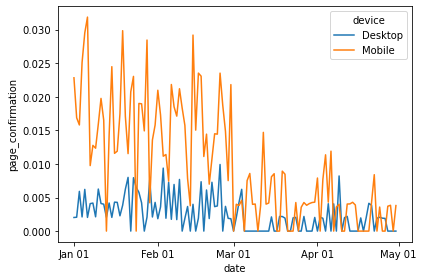

In [16]:
g = sns.lineplot(ctr_ts['date'],ctr_ts['page_confirmation'],hue='device',data=ctr_ts)
g.xaxis.set_major_locator(mdates.MonthLocator())
g.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.show()

## We see the trend line dropped around March

## Lets analyze March More for all pages

In [24]:
funnel = mainframe.groupby(['date','device']).apply(lambda x : pandas.Series( {'to_search':x['page_search'].mean()/x['page_home'].mean(),
                                                             'to_payment':x['page_payment'].mean()/x['page_search'].mean(),
                                                             'to_confirmation':x['page_confirmation'].mean()/x['page_payment'].mean()})).reset_index()

In [25]:
funnel

,date,device,to_search,to_payment,to_confirmation
0,2015-01-01,Desktop,0.519270,0.183594,0.021277
1,2015-01-01,Mobile,0.821918,0.161111,0.172414
2,2015-01-02,Desktop,0.539256,0.168582,0.022727
3,2015-01-02,Mobile,0.784810,0.215054,0.100000
4,2015-01-03,Desktop,0.437870,0.099099,0.136364
...,...,...,...,...,...
235,2015-04-28,Mobile,0.207692,0.296296,0.062500
236,2015-04-29,Desktop,0.483444,0.018265,0.000000
237,2015-04-29,Mobile,0.200000,0.115385,0.000000
238,2015-04-30,Desktop,0.509294,0.036496,0.000000


In [26]:
pandas.melt(funnel,id_vars=['date', 'device'])

,date,device,variable,value
0,2015-01-01,Desktop,to_search,0.519270
1,2015-01-01,Mobile,to_search,0.821918
2,2015-01-02,Desktop,to_search,0.539256
3,2015-01-02,Mobile,to_search,0.784810
4,2015-01-03,Desktop,to_search,0.437870
...,...,...,...,...
715,2015-04-28,Mobile,to_confirmation,0.062500
716,2015-04-29,Desktop,to_confirmation,0.000000
717,2015-04-29,Mobile,to_confirmation,0.000000
718,2015-04-30,Desktop,to_confirmation,0.000000


In [27]:
#### Check What Melt Does In Detail ####

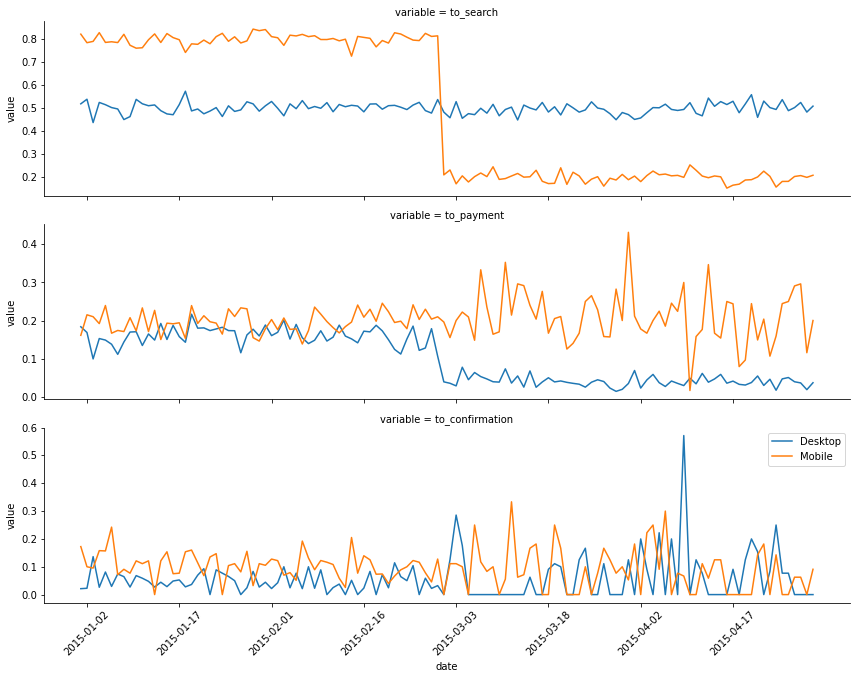

In [28]:
#Make the dataset long for the plot
funnel = pandas.melt(funnel,id_vars=['date', 'device'])
#Plot it
g = sns.FacetGrid(funnel, hue="device", row="variable", aspect=4, sharey=False)
g.map(sns.lineplot, "date", "value")
g.set(xticks=funnel.date[2::30].unique())
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.show()


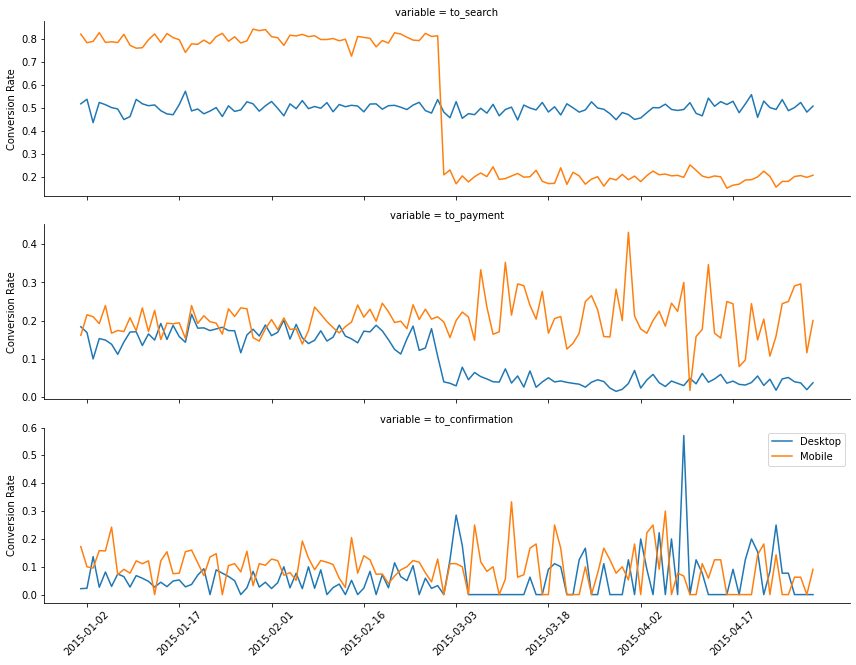

In [29]:
#funnel as a time series
funnel = mainframe.groupby(['date', 'device']).apply(
                    lambda x: pandas.Series({
                            'to_search' : x['page_search'].mean()/x['page_home'].mean(),
                            'to_payment': x['page_payment'].mean()/x['page_search'].mean(),
                            'to_confirmation': x['page_confirmation'].mean()/x['page_payment'].mean()
  })).reset_index()
  
#Make the dataset long for the plot
funnel = pandas.melt(funnel,id_vars=['date', 'device'])
#Plot it
g = sns.FacetGrid(funnel, hue="device", row="variable", aspect=4, sharey=False)
g.map(sns.lineplot, "date", "value")
g.set_axis_labels("", "Conversion Rate")
g.set(xticks=funnel.date[2::30].unique())
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.show()